In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models 

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [11]:
col_names = [
    "zero",
    "one",
    "two",
    "three",
    "four",
    "five",
    "six",
    "seven",
    "eight",
    "nine",
]

In [3]:
# normalize data
X_train = X_train /255.0
X_test= X_test /255.0

In [4]:
# reshape data
X_train_res = X_train.reshape(-1, 28, 28, 1)
X_test_res = X_test.reshape(-1, 28, 28, 1)

In [5]:
# model creation
cnn = models.Sequential([
    layers.Input(shape = (28, 28, 1)),
    layers.Conv2D(128, kernel_size=5, strides=1, activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(32, kernel_size=3, strides=1, activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [6]:
# model compile
cnn.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [8]:
# model training

cnn.fit(X_train_res, y_train, epochs=10, validation_data=(X_test_res, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 132s 68ms/step - accuracy: 0.9760 - loss: 0.0810 - val_accuracy: 0.9810 - val_loss: 0.0597
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 76ms/step - accuracy: 0.9824 - loss: 0.0571 - val_accuracy: 0.9872 - val_loss: 0.0419
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 137s 73ms/step - accuracy: 0.9857 - loss: 0.0467 - val_accuracy: 0.9864 - val_loss: 0.0500
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 117s 62ms/step - accuracy: 0.9884 - loss: 0.0379 - val_accuracy: 0.9841 - val_loss: 0.0566
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9906 - loss: 0.0316 - val_accuracy: 0.9861 - val_loss: 0.0483
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 49ms/step - accuracy: 0.9918 - loss: 0.0272 - val_accuracy: 0.9905 - val_loss: 0.0377
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 101s 54ms/step - accuracy: 0.9925 - loss: 0.0238 - val_accuracy: 0.9891 - val_loss: 0.0399
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 99s 53ms/step - accuracy: 0.9

In [ ]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 128)    │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300,320 (1.15 MB)

 Trainable params: 100,106 (391.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 200,214 (782.09 KB)

In [ ]:
# model save
cnn.save('cnn_model.keras')

In [9]:
y_pred = cnn.predict(X_test_res)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [10]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred.argmax(axis=1))
print("Confusion Matrix :\n", cm)
print("Classification Report :\n", classification_report(y_test, y_pred.argmax(axis=1)))

Confusion Matrix :
 [[ 976    0    1    0    0    0    1    2    0    0]
 [   0 1124    2    3    0    0    1    4    1    0]
 [   1    0 1014    2    4    0    0    9    2    0]
 [   0    0    2 1005    0    1    0    0    2    0]
 [   0    0    0    0  978    0    0    0    0    4]
 [   2    0    0    9    1  868    5    2    0    5]
 [   4    3    1    0    4    1  942    0    3    0]
 [   1    2    2    1    0    0    0 1017    1    4]
 [   0    0    1    0    0    0    0    0  972    1]
 [   0    0    0    1    4    0    0    1    0 1003]]
Classification Report :
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       1.00      0.97      0.99       892
           6       0.99      0.98      0.99  

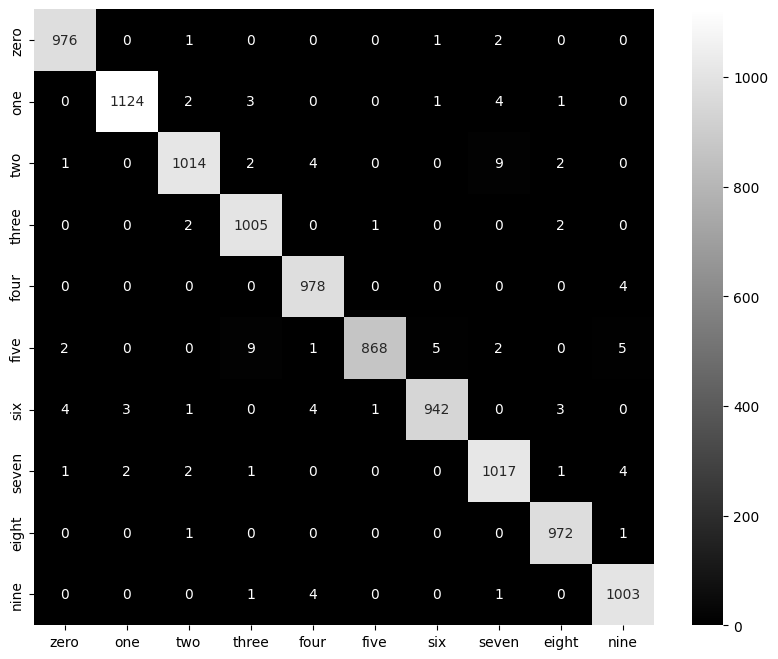

In [12]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, cmap="gray", fmt="d", xticklabels=col_names, yticklabels=col_names
)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
Predicted Digit: seven
Actual Digit: seven


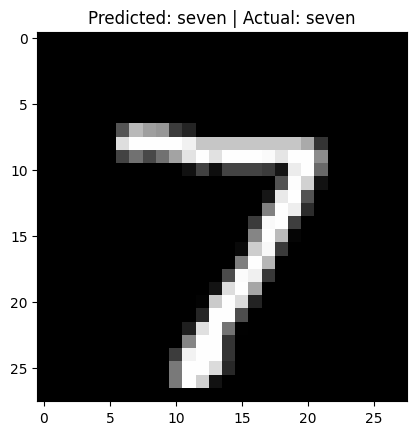

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Predicted Digit: two
Actual Digit: two


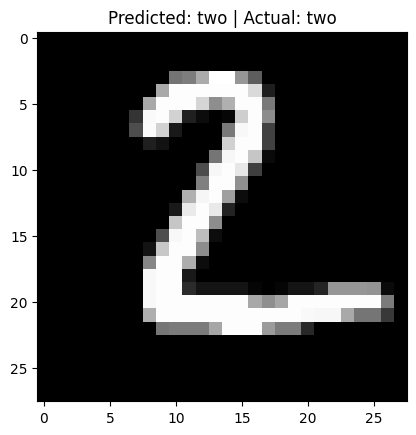

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Predicted Digit: one
Actual Digit: one


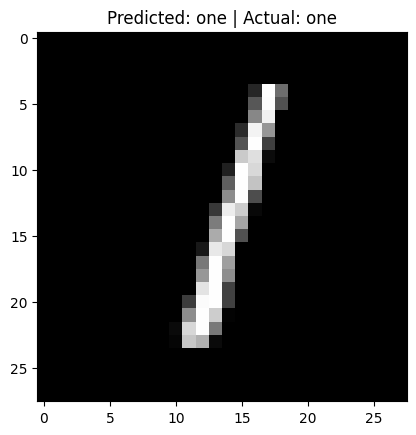

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Predicted Digit: zero
Actual Digit: zero


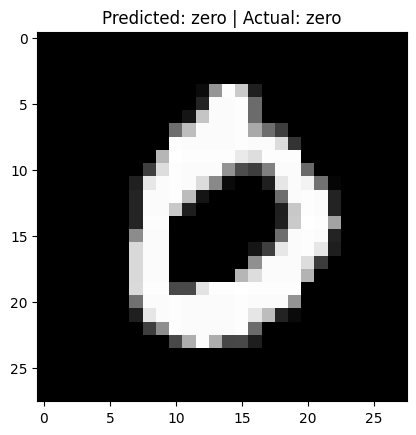

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Predicted Digit: four
Actual Digit: four


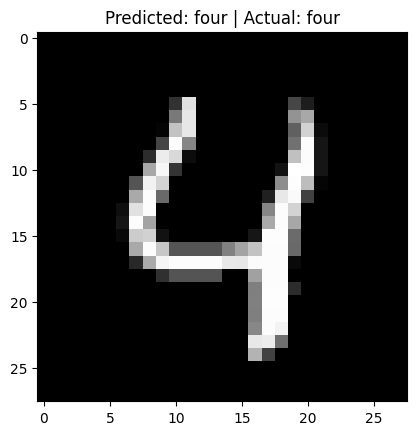

In [14]:
# deployment/ testing phase
saved_model = tf.keras.models.load_model("cnn_model.keras")

(_, _), (X_test_dep, y_test_dep) = tf.keras.datasets.mnist.load_data()

for i in range(5):

    sample_image = X_test_dep[i]
    sample_label = y_test_dep[i]

    sample_image = sample_image.astype("float32") / 255.0
    sample_image_res = sample_image.reshape(-1, 28, 28, 1)

    pred_prob = saved_model.predict(sample_image_res)
    pred_class = pred_prob.argmax(axis=1)[0]

    print(f"Predicted Digit: {col_names[pred_class]}")
    print(f"Actual Digit: {col_names[sample_label]}")

    # visualization
    plt.imshow(sample_image, cmap="gray")
    plt.title(f"Predicted: {col_names[pred_class]} | Actual: {col_names[sample_label]}")
    plt.show()